# Introduction

In part 1 of this assessment, you will complete several requested SQL queries in order to extract data, analyze, and provide insights from a single provided SQL database. You will also visualize the key results of 3 of these queries. There are also several 'Reflection' questions that ask you to write out a text based answer in the provided markdown cell. Following the guided question and answer section, in part 2 you will explore a second dataset on your own using SQL in order to conduct a preliminary analysis. You will be asked to produce a very short slide presentation highlighting the work you did for this second section.

## Objectives
You will be able to:
- Interpret "word problems" and translate them into SQL queries
- Decide and perform whichever type of JOIN is best for retrieving desired data
- Use GROUP BY statements to apply aggregate functions like COUNT, MAX, MIN, and SUM
- Use the HAVING clause to compare different aggregates
- Write subqueries to decompose complex queries
- Visualize data using matplotlib, seaborn, or pandas
- Choose the correct chart type based on the given data


## Part 1: Guided SQL Queries

### Your Task: Querying a Customer Database

![toy car picture](images/toycars.jpg)


### Business Understanding
Your employer sells wholesale miniature models of products such as classic cars, motorcycles, and planes. They want you to pull several reports on different segments of their past customers, in order to better understand past sales as well as determine which customers will receive promotional material. They are also interested in investigating which products have performed the best, as well as having several smaller asks.

In addition to providing the requested data from the SQL database you have also been asked to create some basic visuals to display some of the more insightful information. It is up to your discretion to choose the correct plot/chart type for the data in question. **Questions that want you to visualize the results will be explicitly marked**.

### Data Understanding
You may remember this database from a previous lab. As a refresher, here's the ERD diagram for this database:

![ERD picture](images/ERD.png)

The queries you are asked to write will become more complex over the course of the lab.



### Getting Started
For this assessment you are expected to make use of both sqlite3 and the Pandas libraries in order to write, execute, and return SQL queries as a Pandas DataFrame. Assign each returned answer as its own explicit variable.

For the visualization piece you are expected to utilize either Pandas, Seaborn, or Matplotlib to create your visuals. Make sure you are providing verbose labels and titles according to the data you are being asked to visualize. Do not worry too much about choosing a 'style' or 'context' instead focus on conveying the requested information correctly.

### Step 1: Connect to Data

In the cell below
- Import the necessary libraries
- Establish a connection to the database data.sqlite

In [12]:
# Replace None with your code
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3 

# Create connection to database
conn = sqlite3.connect('data.sqlite')
cur = conn.cursor()

### Step 2: Limited Edition California Product
The California sales rep team is interested in running promotional material for a new limited edition model they are releasing based on the famous San Francisco Cable Cars. This product will only be available to customer stores based in California and given its high price value they want to first target promotional material to existing California customers with a high credit limit. Upon communicating with the accounting department, a credit limit of over 25,000 is considered to be high. 

Execute a SQl query that returns which customers the sales rep team wants to market to first.
*Hint*: Make sure creditLimit is numeric.

In [13]:
q = """ 
SELECT * FROM customers 
LIMIT 5;"""

pd.read_sql(q, conn)

,customerNumber,customerName,contactLastName,contactFirstName,phone,addressLine1,addressLine2,city,state,postalCode,country,salesRepEmployeeNumber,creditLimit
0,103,Atelier graphique,Schmitt,Carine,40.32.2555,"54, rue Royale",,Nantes,,44000,France,1370,21000.00
1,112,Signal Gift Stores,King,Jean,7025551838,8489 Strong St.,,Las Vegas,NV,83030,USA,1166,71800.00
2,114,"Australian Collectors, Co.",Ferguson,Peter,03 9520 4555,636 St Kilda Road,Level 3,Melbourne,Victoria,3004,Australia,1611,117300.00
3,119,La Rochelle Gifts,Labrune,Janine,40.67.8555,"67, rue des Cinquante Otages",,Nantes,,44000,France,1370,118200.00
4,121,Baane Mini Imports,Bergulfsen,Jonas,07-98 9555,Erling Skakkes gate 78,,Stavern,,4110,Norway,1504,81700.00


In [14]:
r = """ 
PRAGMA table_info('customers');
"""

pd.read_sql(r, conn)

,cid,name,type,notnull,dflt_value,pk
0,0,customerNumber,,0,None,0
1,1,customerName,,0,None,0
2,2,contactLastName,,0,None,0
3,3,contactFirstName,,0,None,0
4,4,phone,,0,None,0
5,5,addressLine1,,0,None,0
6,6,addressLine2,,0,None,0
7,7,city,,0,None,0
8,8,state,,0,None,0
9,9,postalCode,,0,None,0


In [15]:
# Replace None with your code
first_customer_segment = pd.read_sql("""
SELECT customerNumber, customerName, phone, state, creditLimit
FROM customers 
WHERE state == 'CA' AND CAST(creditLimit AS REAL) > 25000;
""", conn) 

first_customer_segment

,customerNumber,customerName,phone,state,creditLimit
0,124,Mini Gifts Distributors Ltd.,4155551450,CA,210500.00
1,129,Mini Wheels Co.,6505555787,CA,64600.00
2,161,Technics Stores Inc.,6505556809,CA,84600.00
3,205,Toys4GrownUps.com,6265557265,CA,90700.00
4,239,Collectable Mini Designs Co.,7605558146,CA,105000.00
5,321,Corporate Gift Ideas Co.,6505551386,CA,105000.00
6,347,"Men 'R' US Retailers, Ltd.",2155554369,CA,57700.00
7,450,The Sharp Gifts Warehouse,4085553659,CA,77600.00
8,475,West Coast Collectables Co.,3105553722,CA,55400.00
9,487,Signal Collectibles Ltd.,4155554312,CA,60300.00


### Step 3: International Collectable Campaign

The international sales rep team has reached out to you to help them identify partners for a 'Collectable' marketing campaign that highlights the potential collectors value in purchasing these model kits. They want to try and promote a 'collect them all' mentality. The team had a great idea to partner with any of their international customers (non-US) who have "Collect" in their name as a tie in to the larger theme.

Execute a SQL that returns the customers in question.

In [18]:
# Replace None with your code
partners_collectable = pd.read_sql("""
SELECT customerNumber, customerName, country
FROM customers 
WHERE country != 'USA' AND customerName LIKE '%Collect%';
""", conn) 

partners_collectable

,customerNumber,customerName,country
0,114,"Australian Collectors, Co.",Australia
1,189,"Clover Collections, Co.",Ireland
2,201,"UK Collectables, Ltd.",UK
3,211,"King Kong Collectables, Co.",Hong Kong
4,227,Heintze Collectables,Denmark
5,260,"Royal Canadian Collectables, Ltd.",Canada
6,293,BG&E Collectables,Switzerland
7,353,Reims Collectables,France
8,376,Precious Collectables,Switzerland
9,382,Salzburg Collectables,Austria


## Reflection Question:

Describe the WHERE clause you used in the above query to a non-technical manager who wants to be ensured that you are properly filtering and only selecting the requested data. How is the operator and conditional expression you are using acting to accomplish this?

## Type your answer in markdown here!

The WHERE clause helps used to filter records and extract only the rows that fulfill a specific condition. In our case, our WHERE clause is requesting for international companies outside of the USA (!=) and have the word "Collect" present in their busines name (LIKE %% allows us to search for word that are like Collect)

### Step 4: USA Credit and Inventory Policy - Visual Required
The USA based product team is planning to adjust its credit policies and inventory allocation strategy based on the average credit limit of its customers. They would like to target this strategy at a state level with several goals in mind. 
1. Optimize inventory distribution:
    - States with higher average credit limits might be able to place larger orders, justifying priority in inventory allocation.
    - This could help ensure that states with more purchasing power always have products in stock.
2. Tailor credit policies:
    - Adjust credit limits for new customers based on the state average.
    - Identify states where they might be too conservative or too liberal with credit limits.
3. Target marketing and sales efforts:
    - Focus promotional campaigns on states with higher credit limits, potentially leading to larger orders.
    - Develop strategies to increase sales in states with lower average credit limits.

Execute a SQl query that returns the information required to address this ask.

In [28]:
# Replace None with your code
credit_inventory_policy_df = pd.read_sql(""" 
SELECT state, CAST(AVG(creditLimit) AS REAL) AS avgCreditLimit
FROM customers
WHERE country = 'USA'
GROUP BY state
ORDER BY avgCreditLimit DESC;
""", conn)

In [29]:
credit_inventory_policy_df

,state,avgCreditLimit
0,NH,114200.000000
1,NY,89966.666667
2,PA,84766.666667
3,CA,83854.545455
4,NV,71800.000000
5,MA,70755.555556
6,CT,57350.000000
7,NJ,43000.000000


Once you have the information returned in a dataframe, select an appropriate visualization to represent this data. You are welcome to utilize matplotlib, seaborn, or pandas plotting to produce your visual. Ensure that it has a verbose title and axis labels!

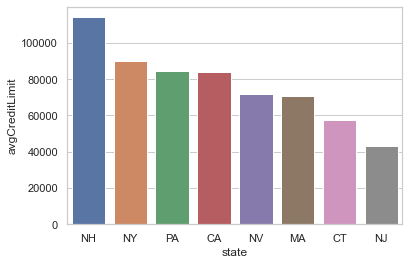

In [31]:
# Replace None with your visual code
# Produce a visual to represent the average credit limit by state

sns.set_theme(style="whitegrid")
sns.barplot(x="state", y="avgCreditLimit", data=credit_inventory_policy_df)
plt.show()

### Step 5: Top Customers - Visual Required
The company is approaching its 10 year anniversary and wants to acknowledge and thank its top customers with personalized communication. They have asked you to determine the top 10 customers based on the total amount of payments made, making sure to return the customer name for clarity. 

Execute a SQl query that returns the information required to address this ask.


In [45]:
# Replace None with your code
top_customers_df = pd.read_sql(
"""
SELECT c.customerNumber, c.customerName,  CAST(p.amount AS REAL) AS amount
FROM customers AS c
    JOIN payments AS p USING(customerNumber)
    ORDER BY amount DESC
LIMIT 10;
""", conn) 

top_customers_df

,customerNumber,customerName,amount
0,141,Euro+ Shopping Channel,120166.58
1,141,Euro+ Shopping Channel,116208.40
2,124,Mini Gifts Distributors Ltd.,111654.40
3,148,"Dragon Souveniers, Ltd.",105743.00
4,124,Mini Gifts Distributors Ltd.,101244.59
5,321,Corporate Gift Ideas Co.,85559.12
6,124,Mini Gifts Distributors Ltd.,85410.87
7,167,Herkku Gifts,85024.46
8,124,Mini Gifts Distributors Ltd.,83598.04
9,114,"Australian Collectors, Co.",82261.22


Once you have the information returned in a dataframe, select an appropriate visualization to represent this data. You are welcome to utilize matplotlib, seaborn, or pandas plotting to produce your visual. Ensure that it has a verbose title and axis labels!

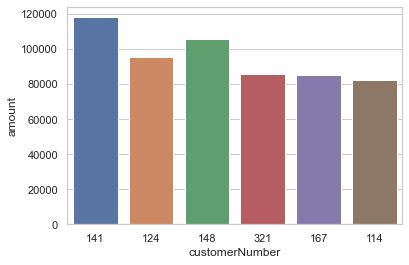

In [48]:
# Replace None with your visual code
# Produce a visual to represent the top ten customers in terms of total payments

sns.set_theme(style="whitegrid")
sns.barplot(x="customerNumber", y="amount", data=top_customers_df, ci=None)
plt.show()

### Step 6: Top Customer + Product Quantities
The product team is running an analysis on popular and common products sold to each customer in order to try and determine what new products they should be looking at to include in their catalog. This data will also be used by individual sales reps to recommend similar products to each customer next time they place an order. 

They have asked you to query information, for each customer, about any product they have purchased 10 or more units of. In addition they would like the full set of data to be sorted in ascending order by the total amount purchased.

Execute a SQl query that returns the information required to address this ask.

Hint: For this one, you'll need to make use of HAVING, GROUP BY, and ORDER BY — make sure you get the order of them correct!

In [51]:
# Replace None with you code
popular_products = pd.read_sql("""
SELECT c.customerNumber, c.customerName, od.productCode,
       SUM(CAST(od.quantityOrdered AS INTEGER)) AS totalQuantity,
       SUM(CAST(od.quantityOrdered AS REAL) * CAST(od.priceEach AS REAL)) AS totalAmount
FROM customers AS c
    JOIN orders AS o USING(customerNumber)
    JOIN orderdetails AS od USING(orderNumber)
GROUP BY c.customerNumber, od.productCode
HAVING totalQuantity >= 10
ORDER BY totalAmount ASC;
""", conn)

popular_products

,customerNumber,customerName,productCode,totalQuantity,totalAmount
0,382,Salzburg Collectables,S24_2972,15,481.50
1,282,Souveniers And Things Co.,S24_3969,15,529.35
2,363,Online Diecast Creations Co.,S24_1937,20,531.00
3,119,La Rochelle Gifts,S32_2509,11,553.52
4,350,Marseille Mini Autos,S24_1937,20,557.60
...,...,...,...,...,...
2526,124,Mini Gifts Distributors Ltd.,S18_2238,123,18780.28
2527,141,Euro+ Shopping Channel,S24_3856,161,21047.69
2528,124,Mini Gifts Distributors Ltd.,S12_3891,137,21811.12
2529,124,Mini Gifts Distributors Ltd.,S12_1108,140,24098.63


### Step 7: Product Analysis - Visual Required

The product team is looking into the demand across its different product lines. They are conducting a comprehensive review of its product portfolio and inventory management strategies. You have been asked to query data pertaining to each different product line, that contains the total quantity ordered and the total number of products for each respective product line. By examining the number of products and total quantity ordered for each product line, the company aims to:
1. Optimize product mix:
    - Identify which product lines have the most diverse offerings (high number of products)
    - Determine which lines are most popular (high total quantity ordered)
    - Compare if lines with more products necessarily lead to more orders
2. Improve inventory management:
    - Adjust stock levels based on the popularity of each product line
    - Identify potential overstocking in lines with low order quantities
    - Ensure adequate variety in high-performing product lines
3. Adjust marketing strategy:
    - Focus promotional efforts on product lines with high potential (many products but lower order quantities)
    - Capitalize on the popularity of high-performing lines in marketing campaigns
4. Advise Product development:
    - Invest in expanding product ranges for lines with high order quantities
    - Consider phasing out or revamping product lines with low numbers of products and low order quantities

Hint: Think about how you can and might have to utilize SQL DISTINCT statement

Execute a SQl query that returns the information required to address this ask.

In [52]:
# Replace None with your code
product_line_analysis = pd.read_sql("""
SELECT p.productLine,
       COUNT(DISTINCT p.productCode) AS numberOfProducts,
       SUM(CAST(od.quantityOrdered AS INTEGER)) AS totalQuantityOrdered
FROM products AS p
    JOIN orderdetails AS od USING(productCode)
GROUP BY p.productLine
ORDER BY totalQuantityOrdered DESC;
""", conn)

product_line_analysis

,productLine,numberOfProducts,totalQuantityOrdered
0,Classic Cars,37,35582
1,Vintage Cars,24,22933
2,Motorcycles,13,12778
3,Planes,12,11872
4,Trucks and Buses,11,11001
5,Ships,9,8532
6,Trains,3,2818


Once you have the information returned in a dataframe, select an appropriate visualization to represent the relationship between total quantity ordered and the number of products in order to perform a preliminary investigation into the question of if more products lead to more orders. You are welcome to utilize matplotlib, seaborn, or pandas plotting to produce your visual. Ensure that it has a verbose title and axis labels!

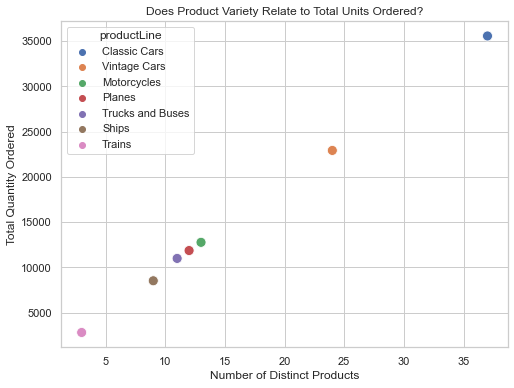

In [57]:
# Replace None with your visual code
# Produce a visual to represent the the relation between number of products and the total amount ordered

plt.figure(figsize=(8, 6))
sns.scatterplot(data=product_line_analysis, x='numberOfProducts', y='totalQuantityOrdered', hue='productLine', s=100)

plt.xlabel('Number of Distinct Products')
plt.ylabel('Total Quantity Ordered')
plt.title('Does Product Variety Relate to Total Units Ordered?')
plt.show()

## Reflection Question:

Please explain your choice in the type of visual you used in order to highlight and represent the data from the above query. In a non-technical manner explain why that chart type makes sense for the information being conveyed. What does this visual convey in the context of the question it was asked for?

## Type your answer in markdown here!

I chose a scatter plot because the question was about whether two numbers are related, not just about which product line is biggest. A scatter plot lets me see if more products in a line tends to come with more units ordered, since each dot represents one product line's pair of values. Looking at the chart, Classic Cars stands out with both the most products and the highest quantity ordered, suggesting variety may help drive sales for that line. However, some other lines don't show this same pattern, meaning more products doesn't automatically equate to more orders. This tells the product team that expanding a line's variety alone isn't a reliable strategy and to focus on expanding specific products and product lines that are proven to sell well i.e Classic Cars


### Step 8: Remote Offices
Upper management is considering a shift to hybrid and remote work for certain locations and roles. They have tasked you with providing them data about employees who work in any office that has fewer than 5 total employees so they can better understand how to support those employees remotely when offices are shut down. 

Be sure to include information about the employees job and supervisor so management can adjust everyone to remote work properly.

Hint: Utilize a subquery to find the relevant offices

Execute a SQl query that returns the information required to address this ask.

In [58]:
# Replace None with your code
remote_office_employees = pd.read_sql("""
SELECT e.employeeNumber, e.firstName, e.lastName, e.jobTitle, e.reportsTo, e.officeCode
FROM employees AS e
WHERE e.officeCode IN (
    SELECT officeCode
    FROM employees
    GROUP BY officeCode
    HAVING COUNT(employeeNumber) < 5
);
""", conn)

remote_office_employees

,employeeNumber,firstName,lastName,jobTitle,reportsTo,officeCode
0,1088,William,Patterson,Sales Manager (APAC),1056,6
1,1188,Julie,Firrelli,Sales Rep,1143,2
2,1216,Steve,Patterson,Sales Rep,1143,2
3,1286,Foon Yue,Tseng,Sales Rep,1143,3
4,1323,George,Vanauf,Sales Rep,1143,3
5,1501,Larry,Bott,Sales Rep,1102,7
6,1504,Barry,Jones,Sales Rep,1102,7
7,1611,Andy,Fixter,Sales Rep,1088,6
8,1612,Peter,Marsh,Sales Rep,1088,6
9,1619,Tom,King,Sales Rep,1088,6


## Reflection Question:

Describe how you decided on the subquery that you used in the query above? This answer can be technically in nature, describing your thought process in how the main query is utilizing the subquery to return the correct data.

## Type your answer in markdown here!

### Step 9: Close the Connection

Now that you are finished executing your queries and retrieving the required information you always want to make sure to close the connection to your database.

In [59]:
# Replace None with your code
conn.close()

### End of Guided Section
In this initial portion of the assessment, you produced several data queries and visualizations for a model company, mainly focused around its customer and product data. You wrote and engineered specific SQL queries to address pertinent questions and asks from the company. Along the way, you utilized many of the major concepts and keywords associated with SQL SELECT queries: FROM, WHERE, GROUP BY, HAVING, ORDER BY, JOIN, SUM, COUNT, and AVG.

## Part 2: Exploratory Analysis with SQL
In this open-ended exploratory section, you will analyze real-world data from the movie industry. As a data analyst, you have the freedom to investigate questions and topics that intrigue you within this dataset. The database schema and Entity-Relationship Diagram (ERD) are provided below for your reference. A general overview and instructions are also provided below.

In [60]:
# Run this cell without changes
import zipfile

zip_file_path = 'im.db.zip'
extract_to_path = './'

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to_path)

# Connection
conn4 = sqlite3.connect('im.db')

# Schema
schema_df = pd.read_sql("""
SElECT * FROM sqlite_master                        
""", conn4)
schema_df

,type,name,tbl_name,rootpage,sql
0,table,movie_basics,movie_basics,2,"CREATE TABLE ""movie_basics"" (\n""movie_id"" TEXT..."
1,table,directors,directors,3,"CREATE TABLE ""directors"" (\n""movie_id"" TEXT,\n..."
2,table,known_for,known_for,4,"CREATE TABLE ""known_for"" (\n""person_id"" TEXT,\..."
3,table,movie_akas,movie_akas,5,"CREATE TABLE ""movie_akas"" (\n""movie_id"" TEXT,\..."
4,table,movie_ratings,movie_ratings,6,"CREATE TABLE ""movie_ratings"" (\n""movie_id"" TEX..."
5,table,persons,persons,7,"CREATE TABLE ""persons"" (\n""person_id"" TEXT,\n ..."
6,table,principals,principals,8,"CREATE TABLE ""principals"" (\n""movie_id"" TEXT,\..."
7,table,writers,writers,9,"CREATE TABLE ""writers"" (\n""movie_id"" TEXT,\n ..."


## The Data

![movie ERD](images/movie_data_erd.jpeg)
### Database Content:

- Source: IMDB
- Time Range: Movies released between 2010 and 2019
- Note: Exclude any movies with a start_year after 2019 as this data is not current or accurate

Available Data Categories:
- Genre
- Runtime
- Personnel (writers, directors, actors)
- Movie ratings

### Objectives:

Initial Exploration:
- Use SQL in combination with Pandas to explore the database
- Identify interesting trends, patterns, or relationships in the data

Business Question Formulation:
- Develop at least one substantial business question for deeper analysis
- Ensure the question is relevant, specific, and can be addressed with the available data

Data Cleaning Assessment:
- Identify potential data cleaning tasks necessary for your deeper analysis
- Note: You are not required to perform the cleaning, only to recognize and list the necessary tasks

Null Value Handling:
- Be aware that the dataset contains null values in certain fields
- Exclude these null values from your exploration
- Do not attempt to input or fill in missing information

### Deliverables:

You need to produce a short slide presentation (3-5 slides) that highlights the three key deliverables below. Utilize a data visualization to support the second deliverable.

1. A summary of your initial data exploration findings
    - Can be bulleted or sentence form
2. At least one well-formulated business question for further analysis
    - Should stem from a relevant trend or pattern your initial exploration identified
3. A list of potential data cleaning tasks identified during your exploration
    - This can and should include things like data normalization/standardization and null handling

Tips for Success:

Begin with broad exploratory queries to understand the data's scope and content. Then focus on honing in on interesting relationships between different data categories. Consider industry trends, audience preferences, or financial aspects when formulating your business question. Pay attention to data quality issues, inconsistencies, or limitations that might affect your analysis. Remember, the goal is to demonstrate your analytical thinking and ability to derive meaningful insights from complex datasets. Good luck with your exploration!

NOTE: You do not need to explore every aspect of this database. Find something that you think is interesting or relevant about the data and focus your exploration there.

# 1. Initial Data Exploration

In [77]:
# Begin your code here
schema_df


,type,name,tbl_name,rootpage,sql
0,table,movie_basics,movie_basics,2,"CREATE TABLE ""movie_basics"" (\n""movie_id"" TEXT..."
1,table,directors,directors,3,"CREATE TABLE ""directors"" (\n""movie_id"" TEXT,\n..."
2,table,known_for,known_for,4,"CREATE TABLE ""known_for"" (\n""person_id"" TEXT,\..."
3,table,movie_akas,movie_akas,5,"CREATE TABLE ""movie_akas"" (\n""movie_id"" TEXT,\..."
4,table,movie_ratings,movie_ratings,6,"CREATE TABLE ""movie_ratings"" (\n""movie_id"" TEX..."
5,table,persons,persons,7,"CREATE TABLE ""persons"" (\n""person_id"" TEXT,\n ..."
6,table,principals,principals,8,"CREATE TABLE ""principals"" (\n""movie_id"" TEXT,\..."
7,table,writers,writers,9,"CREATE TABLE ""writers"" (\n""movie_id"" TEXT,\n ..."


In [78]:
table_movie_basics = pd.read_sql(""" 
SELECT * FROM movie_basics
LIMIT 5;
""", conn4)

table_movie_basics

,movie_id,primary_title,original_title,start_year,runtime_minutes,genres
0,tt0063540,Sunghursh,Sunghursh,2013,175.0,"Action,Crime,Drama"
1,tt0066787,One Day Before the Rainy Season,Ashad Ka Ek Din,2019,114.0,"Biography,Drama"
2,tt0069049,The Other Side of the Wind,The Other Side of the Wind,2018,122.0,Drama
3,tt0069204,Sabse Bada Sukh,Sabse Bada Sukh,2018,NaN,"Comedy,Drama"
4,tt0100275,The Wandering Soap Opera,La Telenovela Errante,2017,80.0,"Comedy,Drama,Fantasy"


In [79]:
table_movie_ratings = pd.read_sql("""
SELECT * FROM movie_ratings
LIMIT 5;
""", conn4)

table_movie_ratings

,movie_id,averagerating,numvotes
0,tt10356526,8.3,31
1,tt10384606,8.9,559
2,tt1042974,6.4,20
3,tt1043726,4.2,50352
4,tt1060240,6.5,21


In [80]:
table_directors = pd.read_sql(""" 
SELECT * FROM directors
LIMIT 5;                              
""", conn4)

table_directors

,movie_id,person_id
0,tt0285252,nm0899854
1,tt0462036,nm1940585
2,tt0835418,nm0151540
3,tt0835418,nm0151540
4,tt0878654,nm0089502


### Genre vs Rating 
- is there a correlation between genre and ratings?
- do specific movie genre's yield higher ratings?

In [ ]:
# considering some movies have multiple genres, this filters to just one genre 
# this helps standardize the data for our analysis 
genre_rating = pd.read_sql("""
SELECT mb.genres, 
       AVG(mr.averagerating) AS avgRating,
       COUNT(mb.movie_id) AS numMovies
FROM movie_basics AS mb
    JOIN movie_ratings AS mr USING(movie_id)
WHERE mb.genres IS NOT NULL 
  AND mb.genres NOT LIKE '%,%'
  AND mb.start_year <= 2019
GROUP BY mb.genres
HAVING COUNT(mb.movie_id) >= 50
ORDER BY avgRating DESC;
""", conn4)

genre_rating

genre_rating

,genres,avgRating,numMovies
0,Music,7.615341,176
1,Documentary,7.293794,10313
2,Sport,6.956818,88
3,Biography,6.858896,163
4,Musical,6.743182,132
5,History,6.605660,106
6,Drama,6.494265,11612
7,Mystery,6.361376,189
8,Adventure,6.272727,176
9,Fantasy,6.201361,147


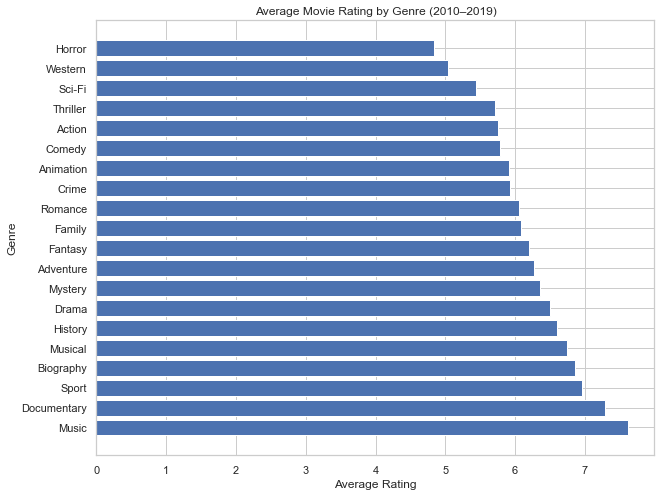

In [89]:
plt.figure(figsize=(10, 8))
plt.barh(genre_rating['genres'], genre_rating['avgRating'])
plt.xlabel('Average Rating')
plt.ylabel('Genre')
plt.title('Average Movie Rating by Genre (2010–2019)')
plt.show()

### Correlation between runtime and ratings 
- Does length of a movie impact ratings? 

In [82]:
runtime_rating = pd.read_sql("""
SELECT mb.movie_id, mb.runtime_minutes, mr.averagerating
FROM movie_basics AS mb
    JOIN movie_ratings AS mr USING(movie_id)
WHERE mb.runtime_minutes IS NOT NULL
  AND mb.start_year <= 2019;
""", conn4)

runtime_rating

,movie_id,runtime_minutes,averagerating
0,tt0063540,175.0,7.0
1,tt0066787,114.0,7.2
2,tt0069049,122.0,6.9
3,tt0100275,80.0,6.5
4,tt0137204,83.0,8.1
...,...,...,...
66231,tt9911774,130.0,8.4
66232,tt9913056,86.0,6.2
66233,tt9913084,75.0,6.2
66234,tt9914286,98.0,8.7


In [ ]:
# check for outliers
runtime_rating['runtime_minutes'].describe()
# max runtime shows as over 51k minutes. This is clearly an outlier and a data cleaning requirement
# min is also 3 mins, which can be considered an outlier and a data cleaning requirement
# next step is to ensure only movies with a runtime between 40 and 300 mins is included in our list as this is a more realistic duration for movies

count    66236.000000
mean        94.654040
std        208.574111
min          3.000000
25%         81.000000
50%         91.000000
75%        104.000000
max      51420.000000
Name: runtime_minutes, dtype: float64

In [84]:
# movies with a runtime between 40 and 300 mins is included in our list
runtime_rating = pd.read_sql("""
SELECT mb.movie_id, mb.runtime_minutes, mr.averagerating
FROM movie_basics AS mb
    JOIN movie_ratings AS mr USING(movie_id)
WHERE mb.runtime_minutes IS NOT NULL
  AND mb.runtime_minutes BETWEEN 40 AND 300
  AND mb.start_year <= 2019;
""", conn4)

runtime_rating['runtime_minutes'].describe()

count    65903.000000
mean        93.743274
std         22.399177
min         40.000000
25%         81.000000
50%         91.000000
75%        104.000000
max        300.000000
Name: runtime_minutes, dtype: float64

In [85]:
correlation = runtime_rating['runtime_minutes'].corr(runtime_rating['averagerating'])
print(f"Correlation between runtime and rating: {correlation:.3f}")

Correlation between runtime and rating: -0.032


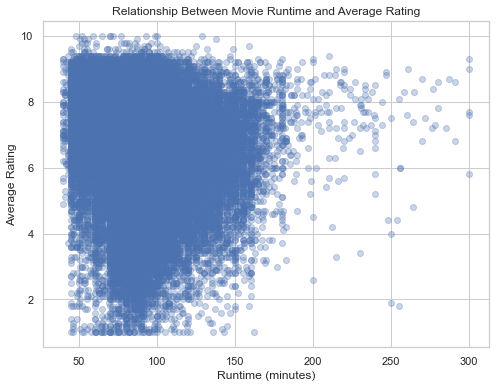

In [86]:
plt.figure(figsize=(8, 6))
plt.scatter(runtime_rating['runtime_minutes'], runtime_rating['averagerating'], alpha=0.3)
plt.xlabel('Runtime (minutes)')
plt.ylabel('Average Rating')
plt.title('Relationship Between Movie Runtime and Average Rating')
plt.show()

# Key Findings

**Runtime vs Ratings**
- To check whether a movie's length has any relationship with how it's rated, I joined `movie_basics` and `movie_ratings` on `movie_id`, filtered out missing runtime values, and excluded unrealistic outliers (runtimes under 40 minutes or over 300 minutes.)
- After cleaning, I calculated the correlation between `runtime_minutes` and `averagerating`, which came out to **-0.032** — essentially no relationship. A scatter plot of the two variables confirmed this visually: ratings are spread widely (roughly 2–10) at nearly every runtime length, with no clear upward or downward trend.

***Conclusion:*** Runtime does not meaningfully predict a movie's rating. This finding ruled out runtime as a useful lever for improving audience reception, and pointed the analysis toward genre as a more promising angle.

**Genre vs Rating**
- I explored whether certain movie genres tend to receive higher or lower average ratings than others. Since the raw `genres` column often stored multiple genres combined into one string (e.g., "Comedy,Documentary,Fantasy"), I filtered the data down to movies with a single listed genre, to allow for a fair, uncombined comparison. I also excluded genres with fewer than 50 movies, since very small sample sizes (in some cases just one movie) were producing misleadingly high or low averages that didn't reflect a real pattern.
- After cleaning, the genres with the highest average ratings were **Music, Documentary, Sport, Biography, and Musical** (roughly 6.7–7.6 average rating), while **Horror, Western, and Sci-Fi** rated lowest (roughly 4.8–5.4). Notably, **Drama and Comedy**, the two highest-volume genres in the dataset, landed only in the middle of the pack, suggesting that producing more movies in a genre doesn't guarantee better audience reception.


**Business Question:** Should studios weigh genre selection more heavily when prioritizing projects aimed at strong audience reception?

**Note** This analysis solely reflects audience/critical *reception*, not commercial performance — genres like Horror and Action are often strong revenue generators despite lower average ratings, so this finding speaks to rating quality specifically, not box office success.
